In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

## Loading & processing data

In [2]:
# Selecting the brain region
select_region = "Isocortex-1"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 227670 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [4]:
# Count the number of cells in each class
class_counts = adata.obs["class"].value_counts()
print(class_counts)

class
01 IT-ET Glut        121827
02 NP-CT-L6b Glut     57507
07 CTX-MGE GABA       13401
06 CTX-CGE GABA       12688
31 OPC-Oligo           6465
30 Astro-Epen          6372
33 Vascular            4813
34 Immune              3607
08 CNU-MGE GABA         432
05 OB-IMN GABA          213
03 OB-CR Glut            89
04 DG-IMN Glut           52
09 CNU-LGE GABA          43
32 OEC                   36
11 CNU-HYa GABA          31
12 HY GABA               30
14 HY Glut               25
25 Pineal Glut           19
13 CNU-HYa Glut           8
16 HY MM Glut             7
24 MY Glut                2
10 LSX GABA               1
15 HY Gnrh1 Glut          1
27 MY GABA                1
Name: count, dtype: int64


In [5]:
# Identify classes with few cells
n_cells_threshold = 100

# Filter out the cells belonging to the identified classes
classes_to_remove = class_counts[class_counts < n_cells_threshold].index.tolist()
adata = adata[~adata.obs["class"].isin(classes_to_remove)].copy()

print(f"Classes with less than {n_cells_threshold} cells ({classes_to_remove}) have been removed.")
adata

Classes with less than 100 cells (['03 OB-CR Glut', '04 DG-IMN Glut', '09 CNU-LGE GABA', '32 OEC', '11 CNU-HYa GABA', '12 HY GABA', '14 HY Glut', '25 Pineal Glut', '13 CNU-HYa Glut', '16 HY MM Glut', '24 MY Glut', '10 LSX GABA', '15 HY Gnrh1 Glut', '27 MY GABA']) have been removed.


AnnData object with n_obs × n_vars = 227325 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [6]:
# # Define the category to remove
# excluded_groups = ["27 MY GABA", "10 LSX GABA", "15 HY Gnrh1 Glut"]

# # Filter out the cells belonging to the specified category
# adata = adata[~adata.obs["class"].isin(excluded_groups)].copy()

# print(f"Cells belonging to category '{excluded_groups}' have been removed.")
# adata

In [6]:
gene_names_df = adata.var.copy()
adata.var.set_index("gene_symbol", inplace=True)

In [7]:
# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)  # Select highly variable genes

### DE

In [8]:
# Perform differential expression analysis
group_by="class"
sc.tl.rank_genes_groups(
    adata,
    groupby=group_by,
    method="wilcoxon",
    use_raw=False
)

In [9]:
# Extract the differential expression results
deg_results = pd.DataFrame({
    group: pd.DataFrame(adata.uns["rank_genes_groups"]["names"])[group]
    for group in adata.uns["rank_genes_groups"]["names"].dtype.names
})

# # Save the dataframe to a CSV file
# output_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{group_by}.csv"
# deg_results.to_csv(output_path, index=False)

# print(f"Differentially expressed genes saved to {output_path}")

In [10]:
deg_results.head()

,01 IT-ET Glut,02 NP-CT-L6b Glut,05 OB-IMN GABA,06 CTX-CGE GABA,07 CTX-MGE GABA,08 CNU-MGE GABA,30 Astro-Epen,31 OPC-Oligo,33 Vascular,34 Immune
0,C1ql3,Hs3st4,H3f3b,Adarb2,Kcnc2,Sox2ot,Plpp3,Olig1,Sparc,Laptm5
1,Cck,Cdh18,Zbtb20,Dlx6os1,Rab3b,Alk,Slc1a3,Qk,Utrn,Inpp5d
2,Tafa1,Foxp2,Msi2,Gad1,Slc32a1,Nkain3,Slc1a2,Gjc3,Zbtb20,Cst3
3,Bdnf,Nxph3,Sox4,Erbb4,Nxph1,Crhbp,Mt1,Sox10,Epas1,Serinc3
4,Nrgn,Rprm,Ttc28,Zfp536,Grip1,Npy,Gja1,Bcas1,Gng5,Csf1r


## Visualization

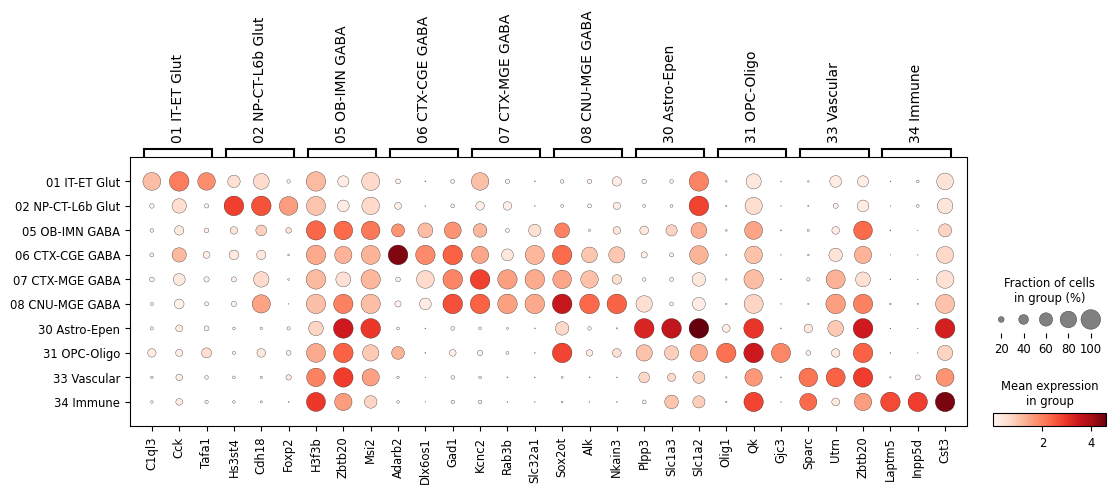

In [27]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=3, dendrogram=False)

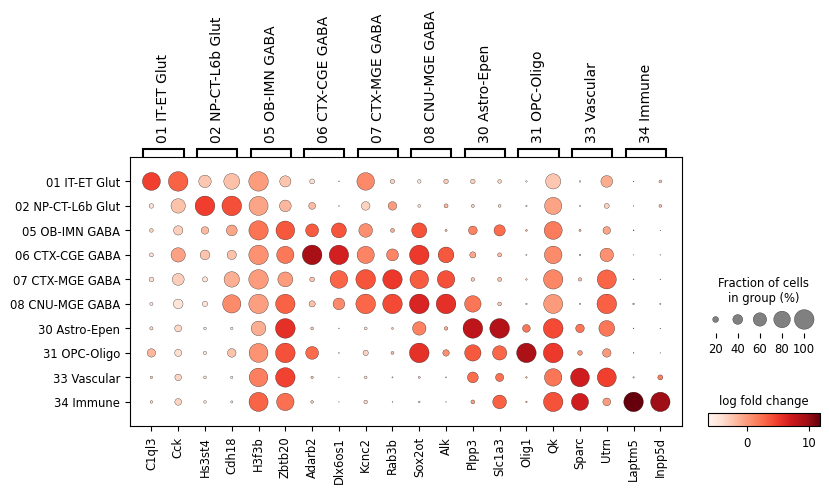

In [ ]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=2, values_to_plot="logfoldchanges", dendrogram=False)

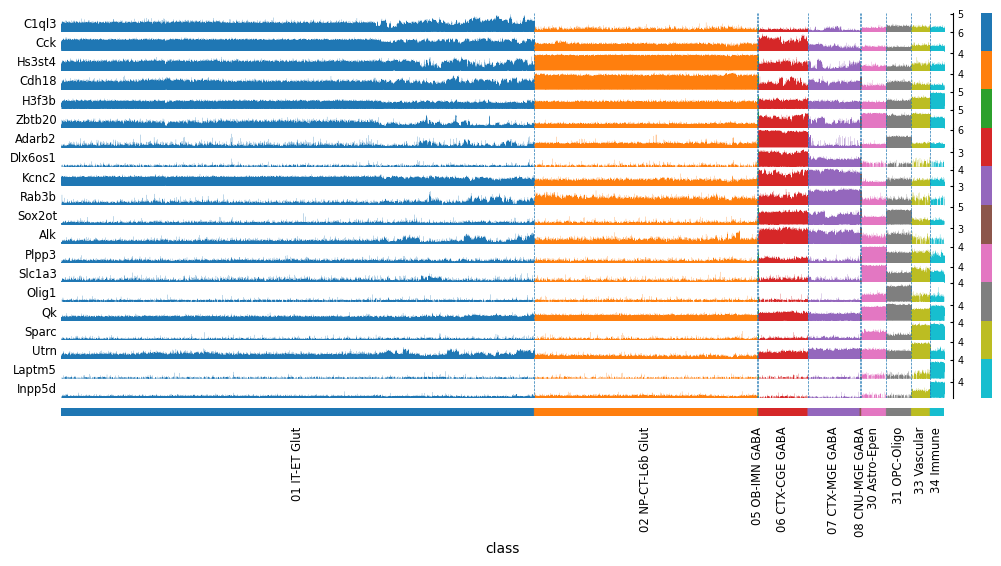

In [15]:
sc.pl.rank_genes_groups_tracksplot(adata, n_genes=2, dendrogram=False)

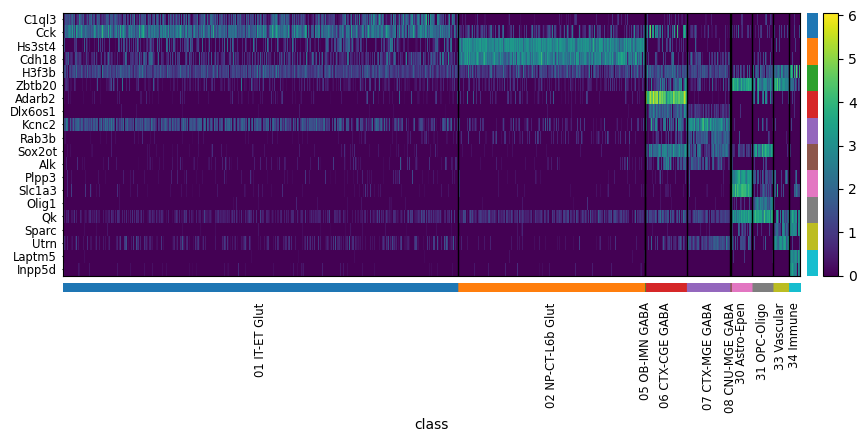

In [ ]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=2, dendrogram=False, swap_axes=True)

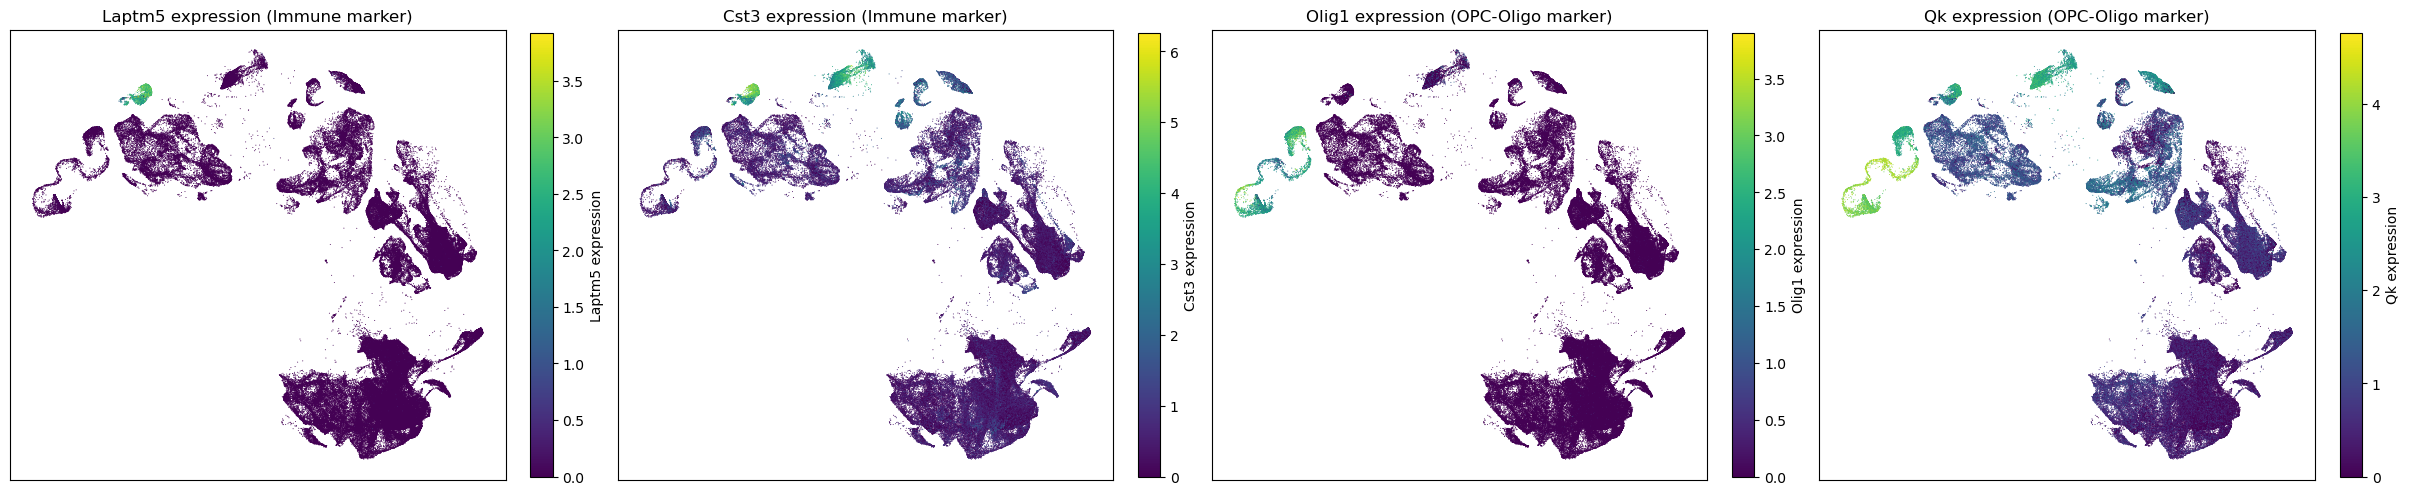

In [30]:
# Selecting genes to plot
top_genes = ["Laptm5", "Cst3", "Olig1", "Qk"]

# Create a figure with subplots
fig, axes = plt.subplots(1, len(top_genes), figsize=(6 * len(top_genes), 6), constrained_layout=True)

# If there's only one gene, make sure axes is iterable
if len(top_genes) == 1:
    axes = [axes]

# Plot the expression of each gene using UMAP coordinates from adata.obs
for ax, gene in zip(axes, top_genes):
    scatter = ax.scatter(
        adata.obs["x"],
        adata.obs["y"],
        c=adata[:, gene].X.toarray().flatten(),
        cmap="viridis",
        s=0.5,
        edgecolor="none"
    )
    fig.colorbar(scatter, ax=ax, shrink = 0.75, label=f"{gene} expression")
    if gene in ["Laptm5", "Cst3"]:
        ax.set_title(f"{gene} expression (Immune marker)")
    elif gene in ["Qk", "Olig1"]:
        ax.set_title(f"{gene} expression (OPC-Oligo marker)")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

plt.show()

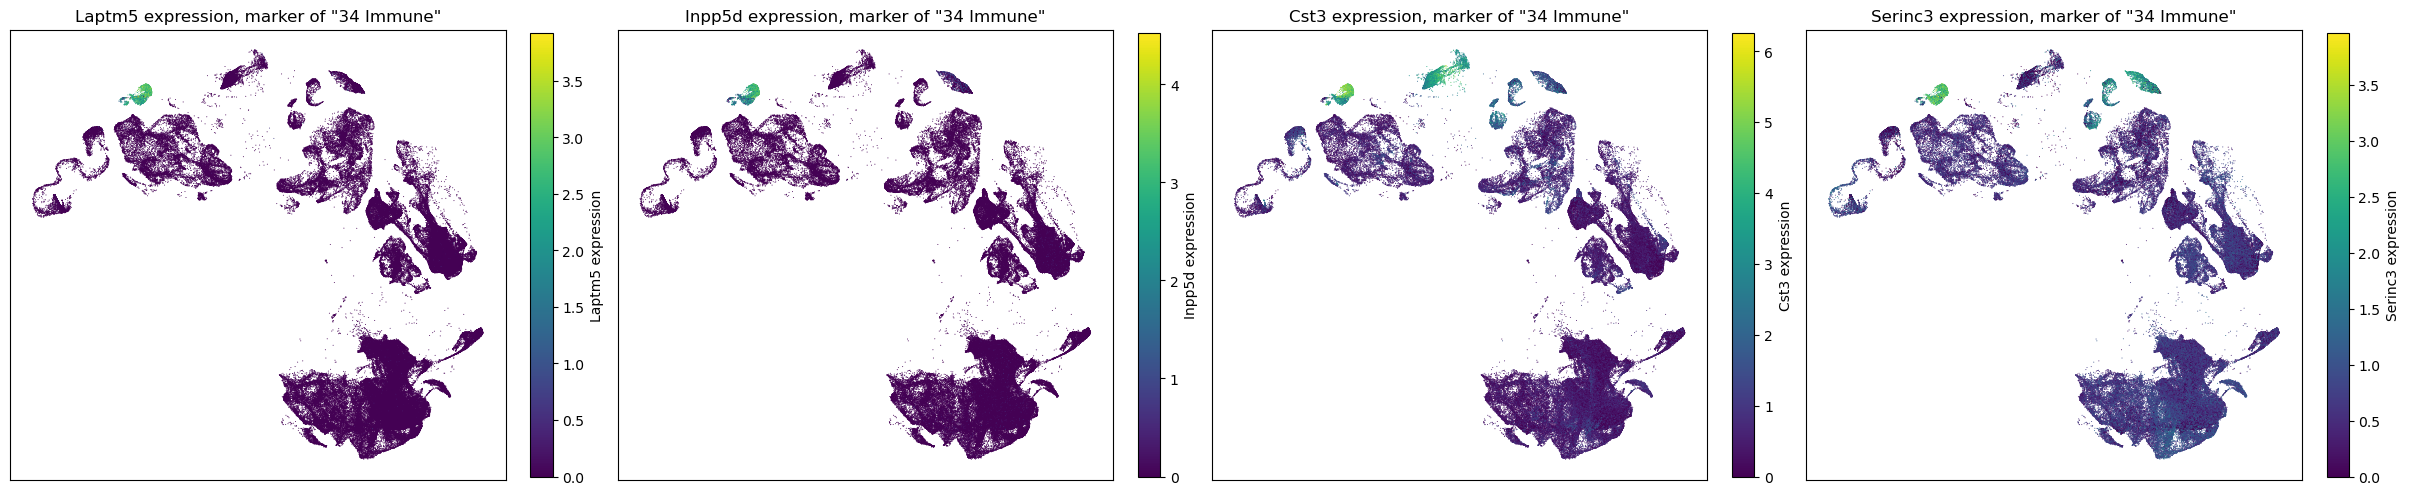

In [35]:
# Select a group and get the top genes
group = "34 Immune"
top_genes = deg_results[group].head(4)

# Create a figure with subplots
fig, axes = plt.subplots(1, len(top_genes), figsize=(6 * len(top_genes), 6), constrained_layout=True)

# If there's only one gene, make sure axes is iterable
if len(top_genes) == 1:
    axes = [axes]

# Plot the expression of each gene using UMAP coordinates from adata.obs
for ax, gene in zip(axes, top_genes):
    scatter = ax.scatter(
        adata.obs["x"],
        adata.obs["y"],
        c=adata[:, gene].X.toarray().flatten(),
        cmap="viridis",
        s=0.5,
        edgecolor="none"
    )
    fig.colorbar(scatter, ax=ax, shrink = 0.75, label=f"{gene} expression")
    ax.set_title(f"{gene} expression, marker of \"{group}\"")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

plt.show()

### Statistical robustness: permutation test via label shuffling

* Shuffle the "class" labels in .obs
* Run DE analysis on the shuffled labels
* Collect top DE genes or statistics (e.g., adjusted p-values or log fold changes)
* Repeat this process multiple times (e.g., 100–1000 permutations)
* Compare your real DEGs to this null distribution to assess how likely they are to arise by chance

In [9]:
from joblib import Parallel, delayed

group_by  = "class"          # same as you used for the original DE call
method    = "wilcoxon"       # or 't-test_overestim_var', etc.
n_perms   = 100              # 1 000 is OK; >5 000 gives smoother tails
n_jobs    = -1               # how many CPU cores to use (‑1 == all)

In [10]:
# ------------------------------------------------------------------
# 1.  Run the observed DE test once                             
# ------------------------------------------------------------------
sc.tl.rank_genes_groups(adata, groupby=group_by, method=method, use_raw=False)

# Capture the observed statistics in a convenient dictionary
def _collect_scores(ad):
    res = {}
    names  = ad.uns["rank_genes_groups"]["names"]
    scores = ad.uns["rank_genes_groups"]["scores"]  # test statistic
    for clust in names.dtype.names:
        for g, s in zip(names[clust], scores[clust]):
            res[(clust, g)] = s
    return res

observed_scores = _collect_scores(adata)

In [11]:
# ------------------------------------------------------------------
# 2.  Single‑permutation helper  (runs in parallel)               
# ------------------------------------------------------------------
def _permute_and_score(ad, seed=None):
    """Shuffle the labels and return a dict { (cluster, gene): score }."""
    rng  = np.random.default_rng(seed)
    ad_p = ad.copy()
    ad_p.obs[group_by] = rng.permutation(ad_p.obs[group_by].values)
    sc.tl.rank_genes_groups(ad_p, groupby=group_by, method=method, use_raw=False)
    return _collect_scores(ad_p)

In [12]:
# ------------------------------------------------------------------
# 3.  Run the permutation test                                   
# ------------------------------------------------------------------
perm_dicts = Parallel(n_jobs=n_jobs, verbose=10)(
                delayed(_permute_and_score)(adata, seed)
                for seed in range(n_perms)
             )

# Bring the permutation scores into a single DataFrame
perm_df = (pd.DataFrame(perm_dicts)          # columns = permutations
             .T                              # rows   = (cluster, gene)
             .fillna(0.0)                    # gene may drop out of top‑N
)
perm_df.index = pd.MultiIndex.from_tuples(perm_df.index,
                                          names=["cluster", "gene"])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of 100 | elapsed:  2.2min remaining: 17.4min
[Parallel(n_jobs=-1)]: Done  22 out of 100 | elapsed:  2.2min remaining:  7.8min
[Parallel(n_jobs=-1)]: Done  33 out of 100 | elapsed:  2.3min remaining:  4.6min
[Parallel(n_jobs=-1)]: Done  44 out of 100 | elapsed:  2.3min remaining:  2.9min
[Parallel(n_jobs=-1)]: Done  55 out of 100 | elapsed:  2.3min remaining:  1.9min
[Parallel(n_jobs=-1)]: Done  66 out of 100 | elapsed:  3.9min remaining:  2.0min
[Parallel(n_jobs=-1)]: Done  77 out of 100 | elapsed:  3.9min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done  88 out of 100 | elapsed:  4.0min remaining:   32.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  4.0min finished


In [ ]:
# ------------------------------------------------------------------
# 4.  Empirical p‑values  (1‑sided: permutation score ≥ observed) 
# ------------------------------------------------------------------
p_vals = {}
for key, obs_s in observed_scores.items():
    perm_s = perm_df.loc[key].values           # vector length = n_perms
    p_vals[key] = (np.sum(perm_s >= obs_s) + 1) / (n_perms + 1)

# --- patch: create a MultiIndex with level names ------------------
pval_s = pd.Series(p_vals)
pval_s.index = pd.MultiIndex.from_tuples(pval_s.index,
                                         names=["cluster", "gene"])

# genes × clusters DataFrame
pval_df = (pval_s
             .unstack(level="cluster")         # or: .unstack(0)
             .sort_index()
)

# Optional: Benjamini–Hochberg FDR across all tests
from statsmodels.stats.multitest import multipletests
flat_p   = pval_df.stack().values
fdr_adj  = multipletests(flat_p, method="fdr_bh")[1]
fdr_df   = pd.Series(fdr_adj,
                     index=pval_df.stack().index).unstack(level="cluster")

# Save for downstream use
# pval_df.to_csv("DEG_permutation_empirical_pvals.csv")
# fdr_df.to_csv("DEG_permutation_FDR.csv")

In [31]:
# -----------------------------------------------
# Choose the cluster you're interested in
# -----------------------------------------------
cluster = "34 Immune"    # <- change this to your target cluster name

# -----------------------------------------------
# Extract Scanpy DE results for that cluster
# -----------------------------------------------
# Convert the rank_genes_groups result to a DataFrame
de_result = pd.DataFrame({
    "gene": adata.uns["rank_genes_groups"]["names"][cluster],
    "score": adata.uns["rank_genes_groups"]["scores"][cluster],
    "logfoldchanges": adata.uns["rank_genes_groups"]["logfoldchanges"][cluster],
    "pval": adata.uns["rank_genes_groups"]["pvals"][cluster],
    "pval_adj": adata.uns["rank_genes_groups"]["pvals_adj"][cluster]
})

# -----------------------------------------------
# Add the empirical p-values from the permutation test
# -----------------------------------------------
# Join using gene name as index
de_result["empirical_pval"] = pval_df[cluster].reindex(de_result["gene"].values).values

# Sort by test statistic (descending), matching Scanpy's order
de_result_sorted = de_result.sort_values("score", ascending=False)

# Optional: view top DEGs by score
de_result_sorted.head(10)

,gene,score,logfoldchanges,pval,pval_adj,empirical_pval
0,Laptm5,102.325294,11.670257,0.0,0.0,0.009901
1,Inpp5d,101.471146,9.586122,0.0,0.0,0.009901
2,Cst3,100.360229,6.652828,0.0,0.0,0.009901
3,Serinc3,99.846977,4.060781,0.0,0.0,0.009901
4,Csf1r,99.571075,11.067130,0.0,0.0,0.009901
5,Zfhx3,99.061943,7.044516,0.0,0.0,0.009901
6,Lyn,98.561783,6.245395,0.0,0.0,0.009901
7,C1qa,98.362793,11.615284,0.0,0.0,0.009901
8,Tyrobp,98.218712,11.134317,0.0,0.0,0.009901
9,C1qc,98.145554,11.758708,0.0,0.0,0.009901


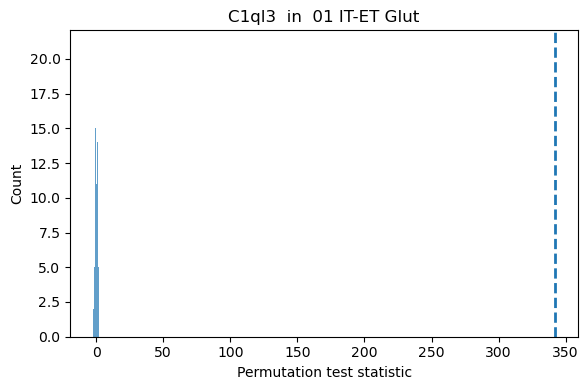

In [32]:
# ------------------------------------------------------------------
# 5.  Visualisation                                              
# ------------------------------------------------------------------
## 5a. Distribution check for a single (cluster, gene) ------------
example_cluster = list(observed_scores.keys())[0][0]   # pick the first cluster
example_gene    = list(observed_scores.keys())[0][1]   # and first gene

perm_scores = perm_df.loc[(example_cluster, example_gene)].values
obs_score   = observed_scores[(example_cluster, example_gene)]

plt.figure(figsize=(6,4))
plt.hist(perm_scores, bins=10, alpha=0.7)
plt.axvline(obs_score, ls="--", lw=2)
plt.xlabel("Permutation test statistic")
plt.ylabel("Count")
plt.title(f"{example_gene}  in  {example_cluster}")
plt.tight_layout()
plt.show()

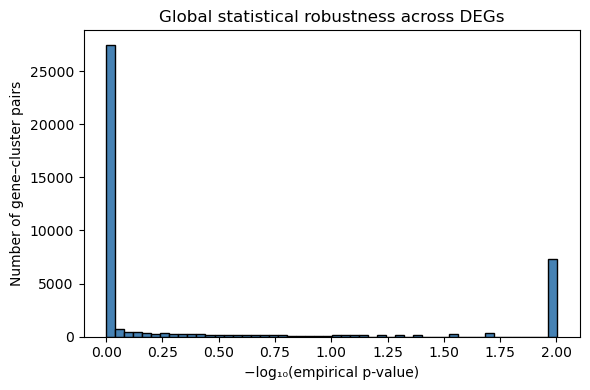

In [ ]:
# Histogram of all permutation p-values (−log10)
all_pvals = pval_df.values.flatten()
all_pvals = all_pvals[~np.isnan(all_pvals)]     # Remove NaNs if any

plt.figure(figsize=(6, 4))
plt.hist(-np.log10(all_pvals + 1e-300), bins=50, color="steelblue", edgecolor="k")
plt.xlabel("−log₁₀(empirical p-value)")
plt.ylabel("Number of gene–cluster pairs")
plt.title("Global statistical robustness across DEGs")
plt.tight_layout()
plt.show()

## Biological relevance: pathway enrichment analysis

In [38]:
from gprofiler import GProfiler

# ---------------------------------------------
# Parameters
# ---------------------------------------------
empirical_threshold = 0.01  # only test DEGs with empirical p < 0.01
organism = "mmusculus"      # mouse gene symbols (use "hsapiens" for human)

# ---------------------------------------------
# Initialize g:Profiler client
# ---------------------------------------------
gp = GProfiler(return_dataframe=True)

# ---------------------------------------------
# Store all results
# ---------------------------------------------
all_enrichments = []

# Loop through each cluster in the empirical p-value table
for cluster in pval_df.columns:
    # 1. Get DE result from Scanpy
    de_result = pd.DataFrame({
        "gene": adata.uns["rank_genes_groups"]["names"][cluster],
        "score": adata.uns["rank_genes_groups"]["scores"][cluster],
        "logfoldchanges": adata.uns["rank_genes_groups"]["logfoldchanges"][cluster],
        "pval": adata.uns["rank_genes_groups"]["pvals"][cluster],
        "pval_adj": adata.uns["rank_genes_groups"]["pvals_adj"][cluster]
    })

    # 2. Add empirical p-values
    de_result["empirical_pval"] = pval_df[cluster].reindex(de_result["gene"].values).values

    # 3. Filter for robust DEGs
    robust_genes = de_result.query("empirical_pval < @empirical_threshold")["gene"].dropna().tolist()

    # Skip clusters with too few robust DEGs
    if len(robust_genes) < 5:
        print(f"Skipping {cluster}: only {len(robust_genes)} robust DEGs.")
        continue

    # 4. Run enrichment using g:Profiler
    res = gp.profile(
        organism=organism,
        query=robust_genes,
        sources=["GO:BP", "GO:MF", "GO:CC"]  # Biological Process, Molecular Function, Cellular Component
    )

    # 5. Add cluster name to results
    res["cluster"] = cluster
    all_enrichments.append(res)

# ---------------------------------------------
# Combine all results into one DataFrame
# ---------------------------------------------
go_results_df = pd.concat(all_enrichments, ignore_index=True)
go_results_df.head()

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,cluster
0,GO:CC,GO:0071944,cell periphery,8.173494e-36,True,"""The broad region around and including the pla...",6940,328,194,27195,0.591463,0.027954,query_1,[GO:0110165],01 IT-ET Glut
1,GO:BP,GO:0007275,multicellular organism development,3.140261e-34,True,"""The biological process whose specific outcome...",4886,329,161,26963,0.489362,0.032951,query_1,"[GO:0032501, GO:0048856]",01 IT-ET Glut
2,GO:BP,GO:0048731,system development,5.118445e-34,True,"""The process whose specific outcome is the pro...",4123,329,147,26963,0.446809,0.035654,query_1,"[GO:0007275, GO:0048856]",01 IT-ET Glut
3,GO:BP,GO:0048856,anatomical structure development,6.389297e-33,True,"""The biological process whose specific outcome...",6290,329,182,26963,0.553191,0.028935,query_1,[GO:0032502],01 IT-ET Glut
4,GO:BP,GO:0032502,developmental process,2.509278e-32,True,"""A biological process whose specific outcome i...",6876,329,190,26963,0.577508,0.027632,query_1,[GO:0008150],01 IT-ET Glut


In [ ]:
# Save to file
go_results_df.to_csv("GO_enrichment_by_cluster.csv", index=False)

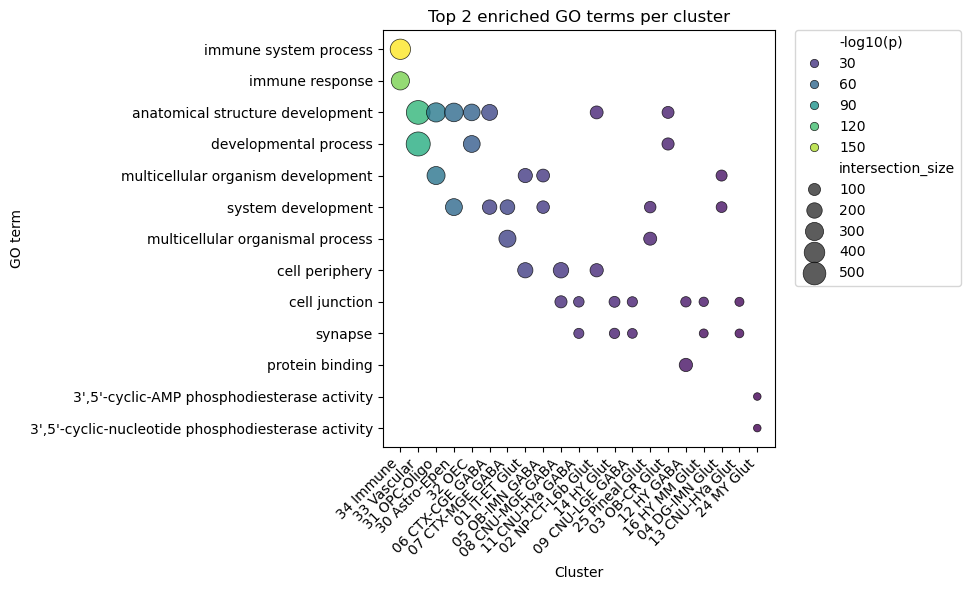

In [ ]:
# ---------------------------------------------
# Parameters
# ---------------------------------------------
top_n = 2  # Top terms per cluster to include

# ---------------------------------------------
# Select top N enriched terms per cluster
# ---------------------------------------------
top_terms_df = (
    go_results_df
    .sort_values("p_value")
    .groupby("cluster")
    .head(top_n)
    .copy()
)

# Shorten term names for better plotting
top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

# Optional: sort GO terms by frequency of appearance across clusters
term_order = (
    top_terms_df["term_display"]
    .value_counts()
    .index.tolist()
)

# ---------------------------------------------
# Create the Dot Plot
# ---------------------------------------------
plt.figure(figsize=(10, max(6, 0.4 * len(term_order))))
sns.scatterplot(
    data=top_terms_df,
    x="cluster",
    y="term_display",
    size="intersection_size",
    hue="-log10(p)",
    sizes=(30, 300),
    palette="viridis",
    edgecolor="black",
    alpha=0.8,
)

# Improve layout
plt.xticks(rotation=45, ha="right")
plt.ylabel("GO term")
plt.xlabel("Cluster")
plt.title(f"Top {top_n} enriched GO terms per cluster")

# Legends
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

### UMAP: expression of top DEGs in one cluster

### Heatmap: expression of top DEGs across clusters - cluster level

In [16]:
def plot_top_deg_expression_heatmap(adata, deg_results, group_by, n_top_genes=1, agg_func="median"):
    """
    Plot a heatmap of aggregated expression values (mean or median) of top DEGs across clusters.

    Parameters:
    - adata: AnnData object
    - deg_results: DataFrame where each column corresponds to a cluster and contains ranked DEG gene names
    - group_by: Column in adata.obs used to group cells (e.g., "leiden", "louvain")
    - n_top_genes: Number of top genes to include per cluster
    - agg_func: Aggregation function to use, either "median" or "mean"
    """
    if agg_func not in ["median", "mean"]:
        raise ValueError("agg_func must be 'median' or 'mean'")

    # Extract top genes per cluster
    top_deg_genes = []
    gene_cluster_mapping = {}
    for cluster in deg_results.columns:
        cluster_top_genes = deg_results[cluster].dropna().head(n_top_genes).tolist()
        top_deg_genes.extend(cluster_top_genes)
        for gene in cluster_top_genes:
            gene_cluster_mapping[gene] = cluster

    top_deg_genes = list(set(top_deg_genes))  # Remove duplicates

    # Aggregate expression by group
    expression_df = adata[:, top_deg_genes].to_df()
    grouped = expression_df.groupby(adata.obs[group_by])

    if agg_func == "mean":
        aggregated_expression = grouped.mean()
    else:  # median
        aggregated_expression = grouped.median()

    # Maintain cluster order if categorical
    if hasattr(adata.obs[group_by], "cat"):
        cluster_order = adata.obs[group_by].cat.categories
        aggregated_expression = aggregated_expression.loc[cluster_order]
    else:
        cluster_order = aggregated_expression.index.tolist()

    # Order genes based on their original cluster association
    ordered_genes = []
    for cluster in cluster_order:
        cluster_genes = [gene for gene in top_deg_genes if gene_cluster_mapping.get(gene) == cluster]
        ordered_genes.extend(cluster_genes)
    
    aggregated_expression = aggregated_expression[ordered_genes]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        aggregated_expression.T,
        cmap="viridis",
        cbar_kws={"label": f"{agg_func.capitalize()} Expression"},
        xticklabels=True,
        yticklabels=ordered_genes
    )
    plt.xlabel("Clusters")
    plt.ylabel("Genes")
    plt.title(f"{agg_func.capitalize()} Expression of Top {n_top_genes} DEGs per Cluster")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_122641/520071919.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = expression_df.groupby(adata.obs[group_by])


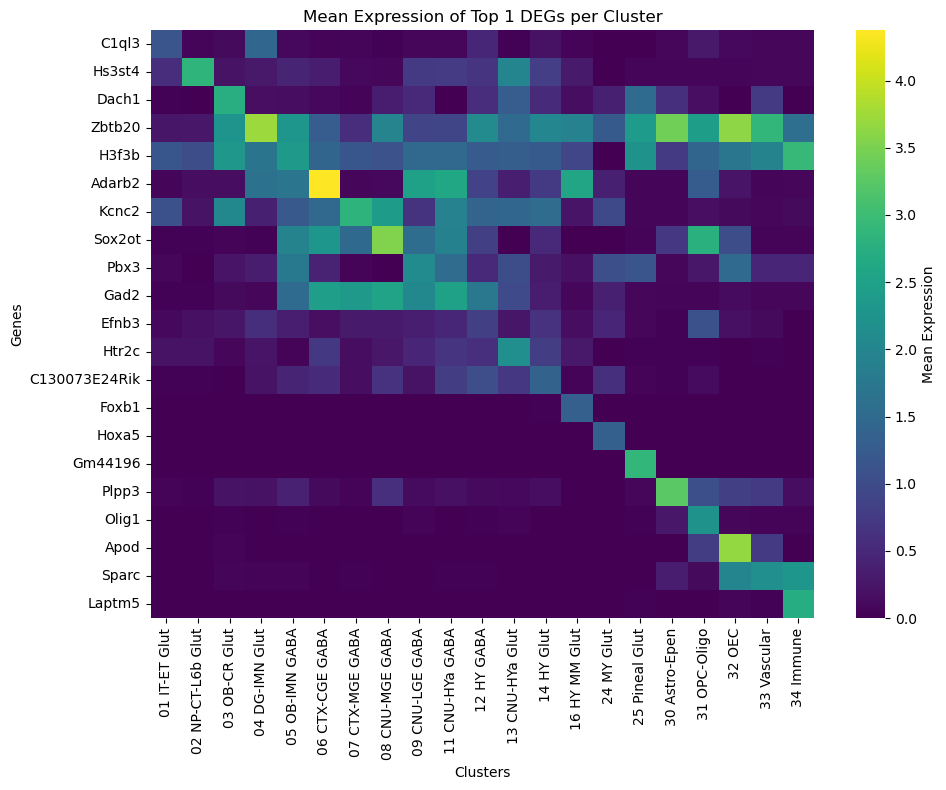

In [17]:
plot_top_deg_expression_heatmap(
    adata=adata,
    deg_results=deg_results,
    group_by="class",
    n_top_genes=1,
    agg_func="mean"
)

### Heatmap: expression of top DEGs across clusters - cell level

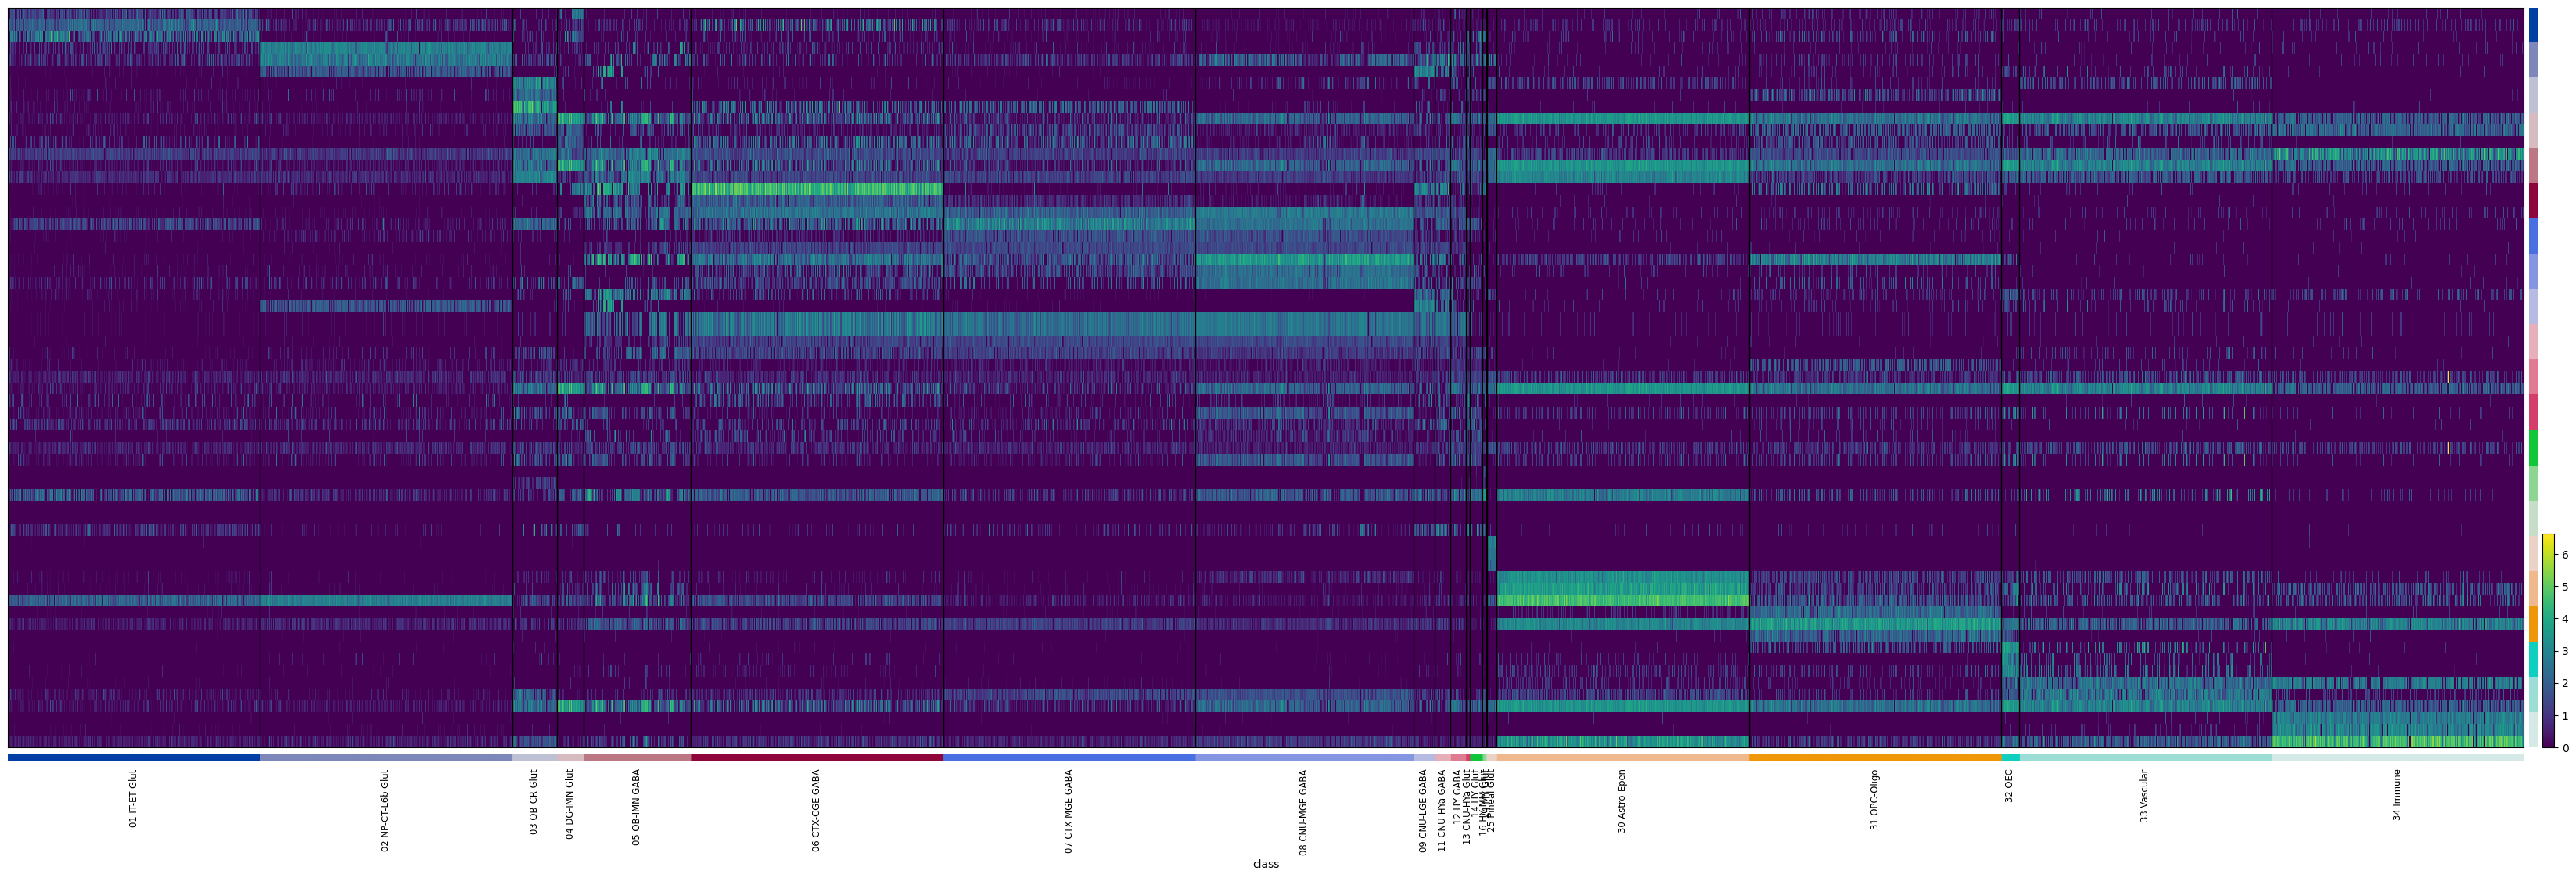

In [15]:
# Define the number of top genes to include per group
n_top_genes = 3

# Extract the top genes for all groups and separate them by group
top_genes_for_heatmap = []
var_group_positions = []
var_group_labels = []
start_idx = 0

for group in deg_results.columns:
    if not deg_results[group].empty:
        group_genes = deg_results[group].dropna().head(n_top_genes).tolist()
        if group_genes:  # Ensure the group has genes
            top_genes_for_heatmap.extend(group_genes)
            var_group_positions.append((start_idx, start_idx + len(group_genes) - 1))
            var_group_labels.append(group)
            start_idx += len(group_genes)

# Compute group sizes
group_sizes = adata.obs[group_by].value_counts()

# Compute scaling factors (normalize based on the largest group)
max_group_size = group_sizes.max() if len(group_sizes) > 0 else 1
scaling_factors = group_sizes / max_group_size  # This replicates your previous calculation

# Store the scaling factors in the AnnData object
adata.obs["scaled_group"] = adata.obs[group_by].map(scaling_factors)

# Downsample cells in large groups to balance the heatmap
max_cells_per_group = 500  # Set a maximum number of cells to display per group

downsampled_indices = []
for group, size in group_sizes.items():
    group_indices = adata.obs[adata.obs[group_by] == group].index.to_list()
    if size > max_cells_per_group:
        sampled_indices = np.random.choice(group_indices, max_cells_per_group, replace=False)
        downsampled_indices.extend(sampled_indices)
    else:
        downsampled_indices.extend(group_indices)

# Ensure correct indexing before subsetting
adata_downsampled = adata[downsampled_indices].copy()

# Adjust the figure size dynamically based on the number of groups and genes
fig_width = max(10, len(var_group_labels) * 2)  # Minimum width of 10, scale with groups
fig_height = max(8, len(top_genes_for_heatmap) * 0.2)  # Minimum height of 8, scale with genes

# Ensure there are genes before plotting
if top_genes_for_heatmap:
    sc.pl.heatmap(
        adata_downsampled,
        var_names=top_genes_for_heatmap,
        groupby=group_by,
        cmap="viridis",
        swap_axes=True,
        figsize=(fig_width, fig_height),
        dendrogram=False,
        var_group_positions=var_group_positions,
        var_group_labels=var_group_labels,
        show=True
    )
else:
    print("No genes selected for the heatmap.")


## Modules

In [18]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
ENSMUSG00000015090,ENSMUSG00000015090,Isocortex-M1,yellow,0.645442,-0.082131,0.055263,0.123491,-0.087391,0.096088,0.129945,0.244009,0.606363,-0.205105
ENSMUSG00000031425,ENSMUSG00000031425,Isocortex-M1,yellow,0.919267,-0.107151,0.070567,0.095239,-0.112462,0.107643,0.243849,0.051845,0.041710,-0.244151
ENSMUSG00000115529,ENSMUSG00000115529,Isocortex-M1,yellow,0.290416,-0.025055,0.009020,0.027299,-0.029463,0.038628,0.236592,0.012456,0.003026,-0.099603
ENSMUSG00000029819,ENSMUSG00000029819,Isocortex-M2,turquoise,-0.003594,0.542115,0.002021,-0.003075,-0.085746,-0.004960,0.046668,0.012330,0.004241,-0.161405
ENSMUSG00000024610,ENSMUSG00000024610,Isocortex-M3,blue,0.006335,-0.033054,0.153545,0.040280,-0.027896,0.001917,-0.002614,0.018507,0.042056,-0.035275


### Heatmap: kME of hub genes across modules

In [19]:
n_top_genes_per_module = 2  # Set the number of top genes to select per module

# Create an empty list to store dataframes for each module
top_genes_by_module = []

# Iterate through each unique module in the "module" column
for module_name in modules_df["module"].unique():
    # Filter the dataframe for the current module
    module_genes = modules_df[modules_df["module"] == module_name]
    
    # Sort the genes by the corresponding kME column in descending order
    sorted_genes = module_genes.sort_values(by=f"kME_{module_name}", ascending=False)
    
    # Select the top genes (you can adjust the number of top genes as needed)
    top_genes = sorted_genes.head(n_top_genes_per_module)
    
    # Append the top genes dataframe to the list
    top_genes_by_module.append(top_genes)

# Combine all the top genes dataframes into a single dataframe
top_genes_df = pd.concat(top_genes_by_module, ignore_index=True)

# Display the resulting dataframe
top_genes_df.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
0,ENSMUSG00000033579,Isocortex-M1,yellow,0.931046,-0.094431,0.014312,0.035500,-0.096881,0.045765,0.305594,0.001473,0.003802,-0.213210
1,ENSMUSG00000037625,Isocortex-M1,yellow,0.926951,-0.103769,0.018537,0.047911,-0.095544,0.037631,0.131973,0.026364,0.068962,-0.209419
2,ENSMUSG00000026787,Isocortex-M2,turquoise,-0.011908,0.913981,-0.012700,-0.016992,-0.158939,-0.021097,0.069336,0.004123,-0.000682,-0.266210
3,ENSMUSG00000037771,Isocortex-M2,turquoise,-0.016164,0.903847,-0.018195,-0.022709,-0.157596,-0.028394,0.060217,-0.002996,-0.001836,-0.259361
4,ENSMUSG00000024621,Isocortex-M3,blue,0.032446,-0.113386,0.967422,0.084476,-0.085543,0.008932,-0.022843,-0.010405,-0.004951,-0.200912


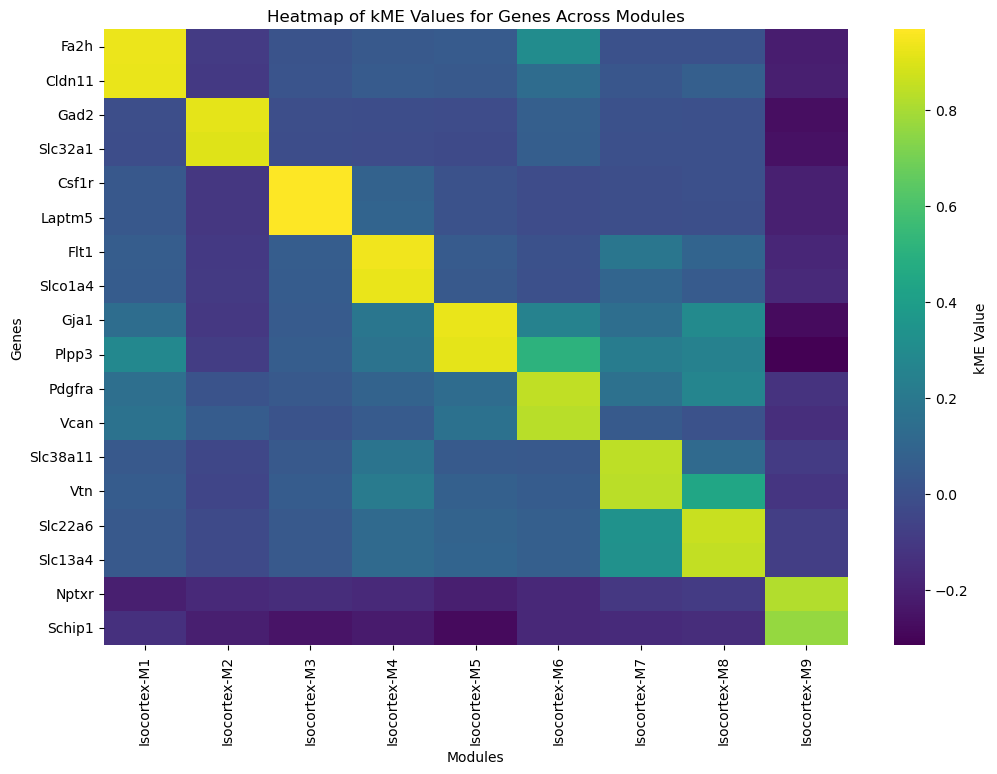

In [20]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [col.replace("kME_", "") for col in heatmap_data.columns]  # Simplify column names

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Genes Across Modules")

plt.show()

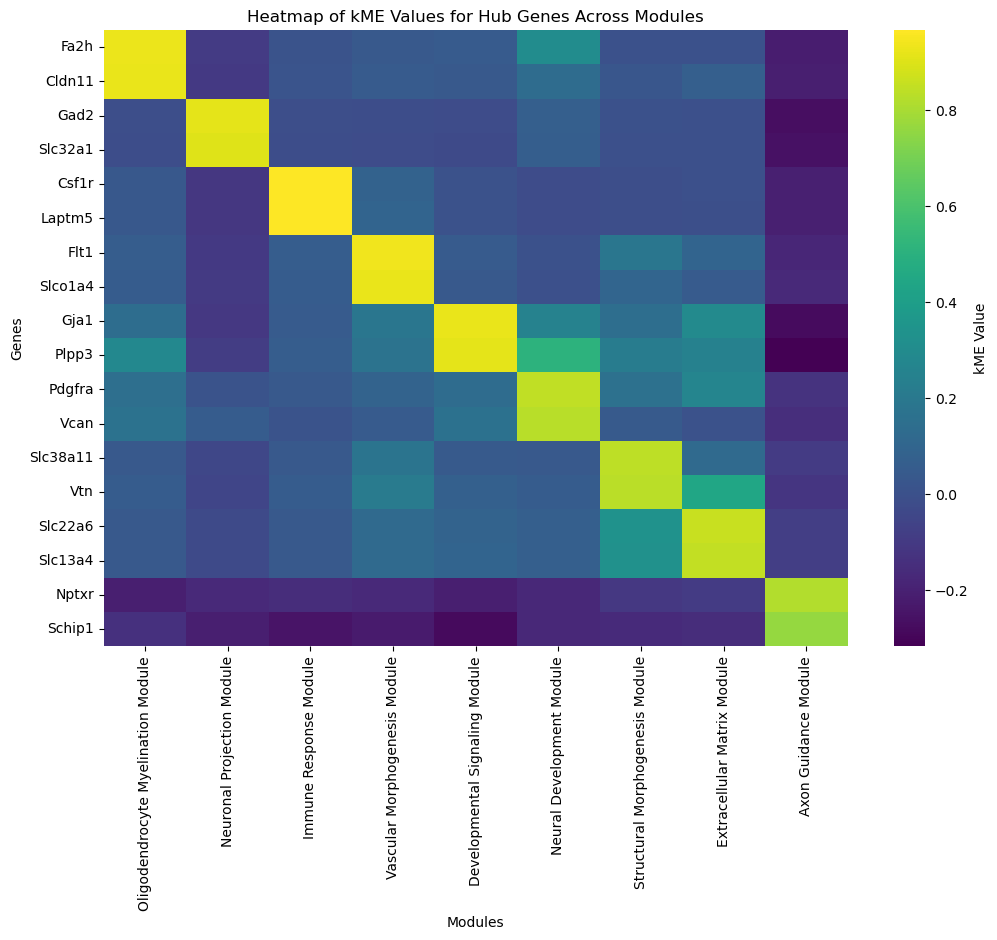

In [21]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Define a dictionary with old module names as keys and new module names as values
module_name_mapping = {
    "Isocortex-M1": "Oligodendrocyte Myelination Module",
    "Isocortex-M2": "Neuronal Projection Module",
    "Isocortex-M3": "Immune Response Module",
    "Isocortex-M4": "Vascular Morphogenesis Module",
    "Isocortex-M5": "Developmental Signaling Module",
    "Isocortex-M6": "Neural Development Module",
    "Isocortex-M7": "Structural Morphogenesis Module",
    "Isocortex-M8": "Extracellular Matrix Module",
    "Isocortex-M9": "Axon Guidance Module",
}

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [
    module_name_mapping.get(col.replace("kME_", ""), col.replace("kME_", ""))
    for col in heatmap_data.columns
]

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Hub Genes Across Modules")

plt.show()
